In [2]:
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print(x_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 482s 3us/step


d:\SMIT\Machine Learning\DeepLearning\Beginner Level Projects\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)


In [5]:
class_names = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

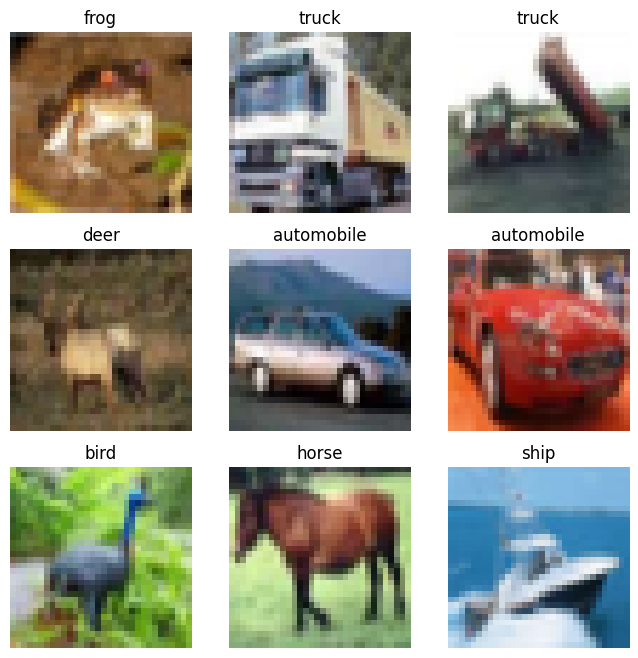

In [6]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

## Normalize

In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## FIRST CNN MODEL

In [8]:
model = keras.Sequential([

    keras.layers.Conv2D(32,(3,3),
                        activation='relu',
                        input_shape=(32,32,3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

d:\SMIT\Machine Learning\DeepLearning\Beginner Level Projects\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train

In [17]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    validation_data=(x_test,y_test)
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7313 - loss: 0.7691 - val_accuracy: 0.6977 - val_loss: 0.8970
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.7503 - loss: 0.7158 - val_accuracy: 0.6861 - val_loss: 0.9316
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7654 - loss: 0.6736 - val_accuracy: 0.6947 - val_loss: 0.9043
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7793 - loss: 0.6296 - val_accuracy: 0.6936 - val_loss: 0.9381
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.7927 - loss: 0.5909 - val_accuracy: 0.7042 - val_loss: 0.9072
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.8041 - loss: 0.5573 - val_accuracy: 0.6958 - val_loss: 0.9376
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 17ms/step - accuracy: 0.8153 - loss: 0.5237 - val_accuracy: 0.6937 - val_loss: 0.9688
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8271 -

## Training Graph (IMPORTANT)

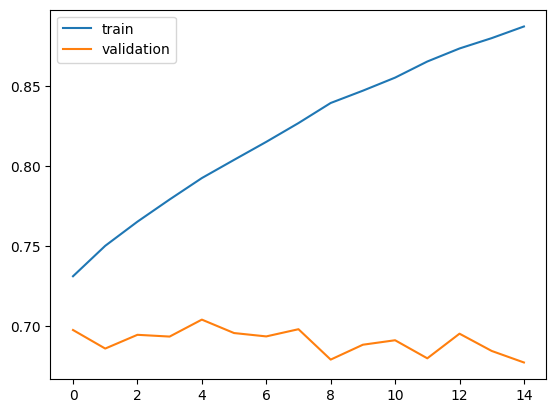

In [18]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()

## Prediction Check (REAL TEST)

In [19]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


## One Image Test

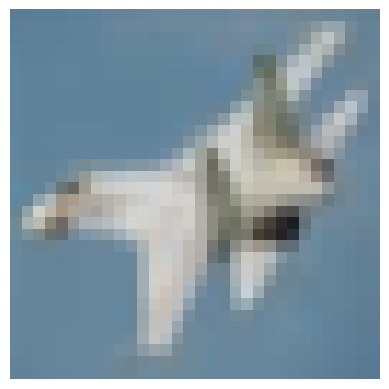

In [20]:
index = 10

plt.imshow(x_test[index])
plt.axis('off')
plt.show()

## What Models output

In [21]:
index = 10 

predicted_label = class_names[np.argmax(predictions[index])]
true_label = class_names[y_test[index][0]]

print("Prediction:", predicted_label)
print("Actual:", true_label)

Prediction: airplane
Actual: airplane


## Engineer Move

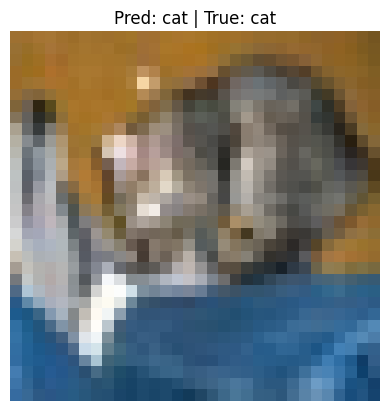

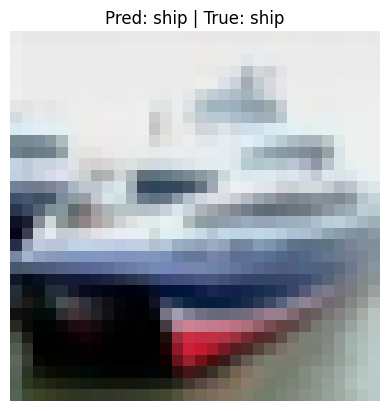

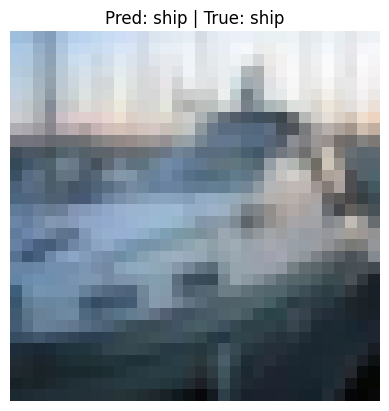

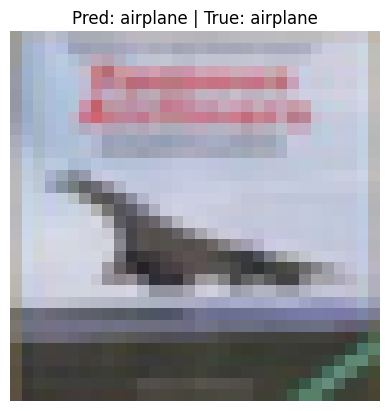

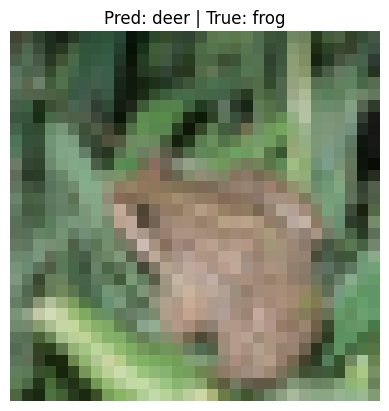

In [22]:
for i in range(5):
    plt.imshow(x_test[i])
    plt.title(
        f"Pred: {class_names[np.argmax(predictions[i])]} | "
        f"True: {class_names[y_test[i][0]]}"
    )
    plt.axis('off')
    plt.show()